In [1]:
# ============================================================
# MedAgent
# Notebook 04
# Model Evaluation
# ============================================================

"""
Project:
MedAgent

Notebook:
04_model_evaluation.ipynb

Objective:
Evaluate the trained DenseNet121 model on the
held-out NIH ChestXray14 Test Dataset.

Author:
Navaddip Chowdary

Dataset:
NIH ChestXray14

Model:
DenseNet121

Framework:
PyTorch
"""

'\nProject:\nMedAgent\n\nNotebook:\n04_model_evaluation.ipynb\n\nObjective:\nEvaluate the trained DenseNet121 model on the\nheld-out NIH ChestXray14 Test Dataset.\n\nAuthor:\nNavaddip Chowdary\n\nDataset:\nNIH ChestXray14\n\nModel:\nDenseNet121\n\nFramework:\nPyTorch\n'

In [2]:
# ============================================================
# Imports
# ============================================================

import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.models import (
    densenet121,
    DenseNet121_Weights
)

warnings.filterwarnings("ignore")

In [3]:
# ============================================================
# Project Directories
# ============================================================

PROJECT_DIR = Path.cwd().parent

DATA_DIR = PROJECT_DIR / "data"

RAW_DIR = DATA_DIR / "raw"

PROCESSED_DIR = DATA_DIR / "processed"

MODEL_DIR = PROJECT_DIR / "models"

OUTPUT_DIR = PROJECT_DIR / "outputs"

EVAL_DIR = OUTPUT_DIR / "evaluation"

EVAL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(EVAL_DIR)

c:\Users\HP\MED-AGENT\outputs\evaluation


In [4]:
# ============================================================
# Configuration
# ============================================================

IMAGE_SIZE = 224

BATCH_SIZE = 32

DEVICE = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else "cpu"

)

print("Device :", DEVICE)

Device : cuda


In [5]:
# ============================================================
# Load Disease Classes
# ============================================================

with open(

    PROCESSED_DIR / "disease_classes.json",

    "r"

) as f:

    label_columns = json.load(f)

print("=" * 60)

print("Disease Classes")

print("=" * 60)

print(f"Total Classes : {len(label_columns)}")

print()

for i, disease in enumerate(label_columns):

    print(f"{i+1:02d}. {disease}")

Disease Classes
Total Classes : 15

01. Atelectasis
02. Cardiomegaly
03. Consolidation
04. Edema
05. Effusion
06. Emphysema
07. Fibrosis
08. Hernia
09. Infiltration
10. Mass
11. No Finding
12. Nodule
13. Pleural_Thickening
14. Pneumonia
15. Pneumothorax


In [6]:
# ============================================================
# Load Test Metadata
# ============================================================

test_df = pd.read_csv(

    PROCESSED_DIR / "test_metadata.csv"

)

print("=" * 60)

print("Test Dataset")

print("=" * 60)

print(test_df.shape)

display(test_df.head())

Test Dataset
(17448, 29)


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Sex,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,...,Emphysema,Fibrosis,Hernia,Infiltration,Mass,No Finding,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax
0,00000004_000.png,Mass|Nodule,0,4,82,M,AP,2500,2048,0.168,...,0,0,0,0,1,0,1,0,0,0
1,00000018_000.png,No Finding,0,18,75,M,PA,2500,2048,0.168,...,0,0,0,0,0,1,0,0,0,0
2,00000035_000.png,No Finding,0,35,79,M,PA,2754,2873,0.143,...,0,0,0,0,0,1,0,0,0,0
3,00000035_001.png,No Finding,1,35,80,M,PA,2718,2973,0.143,...,0,0,0,0,0,1,0,0,0,0
4,00000045_000.png,Cardiomegaly,0,45,70,F,PA,2500,2048,0.168,...,0,0,0,0,0,0,0,0,0,0


In [7]:
# ============================================================
# Image Lookup
# ============================================================

IMAGE_DIR = RAW_DIR / "images"

image_lookup = {}

folders = sorted(

    IMAGE_DIR.glob("images_*")

)

for folder in folders:

    actual_folder = folder / "images"

    for img in actual_folder.glob("*.png"):

        image_lookup[img.name] = img

print(

    f"Images Indexed : {len(image_lookup):,}"

)

Images Indexed : 112,120


In [8]:
# ============================================================
# Test Transform
# ============================================================

test_transform = transforms.Compose([

    transforms.Resize(

        (IMAGE_SIZE, IMAGE_SIZE)

    ),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[0.5],

        std=[0.5]

    )

])

print(test_transform)

Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.5], std=[0.5])
)


In [9]:
# ============================================================
# Custom Dataset
# ============================================================

from torch.utils.data import Dataset

class ChestXrayDataset(Dataset):

    def __init__(
        self,
        dataframe,
        image_lookup,
        label_columns,
        transform=None
    ):

        self.df = dataframe.reset_index(drop=True)

        self.image_lookup = image_lookup

        self.transform = transform

        self.image_names = self.df["Image Index"].tolist()

        self.labels = self.df[label_columns].to_numpy(dtype=np.float32)

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        image_path = self.image_lookup[self.image_names[idx]]

        image = Image.open(image_path).convert("L")

        if self.transform:

            image = self.transform(image)

        label = torch.from_numpy(self.labels[idx])

        return image, label

In [10]:
# ============================================================
# Test Dataset
# ============================================================

test_dataset = ChestXrayDataset(

    dataframe=test_df,

    image_lookup=image_lookup,

    label_columns=label_columns,

    transform=test_transform

)

test_loader = DataLoader(

    dataset=test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=0,

    pin_memory=False

)

print("="*60)

print("Test Dataset Ready")

print("="*60)

print(f"Images : {len(test_dataset)}")

Test Dataset Ready
Images : 17448


In [11]:
# ============================================================
# Build DenseNet121
# ============================================================

model = densenet121(

    weights=None

)

old_conv = model.features.conv0

model.features.conv0 = nn.Conv2d(

    1,

    old_conv.out_channels,

    kernel_size=old_conv.kernel_size,

    stride=old_conv.stride,

    padding=old_conv.padding,

    bias=False

)

num_features = model.classifier.in_features

model.classifier = nn.Linear(

    num_features,

    len(label_columns)

)

In [12]:
# ============================================================
# Load Best Model
# ============================================================

checkpoint = torch.load(

    MODEL_DIR /

    "checkpoints" /

    "best_model.pth",

    map_location=DEVICE

)

model.load_state_dict(

    checkpoint["model_state_dict"]

)

model = model.to(DEVICE)

model.eval()

print("="*60)

print("Best Model Loaded")

print("="*60)

Best Model Loaded


In [13]:
# ============================================================
# Verify Model
# ============================================================

images, labels = next(

    iter(test_loader)

)

images = images.to(DEVICE)

with torch.no_grad():

    outputs = model(images)

print("Input :", images.shape)

print("Output :", outputs.shape)

Input : torch.Size([32, 1, 224, 224])
Output : torch.Size([32, 15])


In [14]:
print("="*60)

print("Evaluation Ready")

print("="*60)

print(f"Test Images : {len(test_dataset)}")

print(f"Diseases : {len(label_columns)}")

print("Model : DenseNet121")

print("Device :", DEVICE)

Evaluation Ready
Test Images : 17448
Diseases : 15
Model : DenseNet121
Device : cuda


In [15]:
# Inference on Test Dataset

This section performs inference on the entire test dataset.

Outputs collected:

- Ground Truth Labels
- Raw Logits
- Sigmoid Probabilities
- Binary Predictions

SyntaxError: invalid syntax (3263450309.py, line 3)

In [16]:
# ============================================================
# Storage Lists
# ============================================================

all_labels = []

all_logits = []

all_probabilities = []

all_predictions = []

print("=" * 60)
print("Storage Lists Created")
print("=" * 60)

Storage Lists Created


In [17]:
# ============================================================
# Run Inference
# ============================================================

from tqdm import tqdm

model.eval()

with torch.no_grad():

    progress_bar = tqdm(
        test_loader,
        desc="Running Inference"
    )

    for images, labels in progress_bar:

        images = images.to(DEVICE)

        outputs = model(images)

        probabilities = torch.sigmoid(outputs)

        predictions = (probabilities >= 0.5).float()

        all_logits.append(outputs.cpu())

        all_probabilities.append(probabilities.cpu())

        all_predictions.append(predictions.cpu())

        all_labels.append(labels)

Running Inference: 100%|██████████| 546/546 [12:04<00:00,  1.33s/it]


In [18]:
# ============================================================
# Convert to Tensors
# ============================================================

all_logits = torch.cat(all_logits)

all_probabilities = torch.cat(all_probabilities)

all_predictions = torch.cat(all_predictions)

all_labels = torch.cat(all_labels)

print("=" * 60)

print("Tensor Shapes")

print("=" * 60)

print("Labels        :", all_labels.shape)

print("Logits        :", all_logits.shape)

print("Probabilities :", all_probabilities.shape)

print("Predictions   :", all_predictions.shape)

Tensor Shapes
Labels        : torch.Size([17448, 15])
Logits        : torch.Size([17448, 15])
Probabilities : torch.Size([17448, 15])
Predictions   : torch.Size([17448, 15])


In [19]:
# ============================================================
# Convert to NumPy
# ============================================================

labels_np = all_labels.numpy()

logits_np = all_logits.numpy()

probabilities_np = all_probabilities.numpy()

predictions_np = all_predictions.numpy()

print("Conversion Complete")

Conversion Complete


In [20]:
    # ============================================================
# Verification
# ============================================================

print("=" * 60)

print("Verification")

print("=" * 60)

print("Ground Truth Shape :", labels_np.shape)

print("Probability Shape  :", probabilities_np.shape)

print("Prediction Shape   :", predictions_np.shape)

print()

print("First Image Prediction")

print(predictions_np[0])

print()

print("Ground Truth")

print(labels_np[0])

Verification
Ground Truth Shape : (17448, 15)
Probability Shape  : (17448, 15)
Prediction Shape   : (17448, 15)

First Image Prediction
[0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0.]

Ground Truth
[0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0.]


In [21]:
# ============================================================
# Number of Positive Predictions
# ============================================================

prediction_count = predictions_np.sum(axis=0)

prediction_df = pd.DataFrame({

    "Disease": label_columns,

    "Positive Predictions": prediction_count.astype(int)

})

prediction_df

,Disease,Positive Predictions
0,Atelectasis,8365
1,Cardiomegaly,5690
2,Consolidation,7989
3,Edema,5309
4,Effusion,6906
5,Emphysema,3143
6,Fibrosis,3955
7,Hernia,3016
8,Infiltration,9220
9,Mass,5119


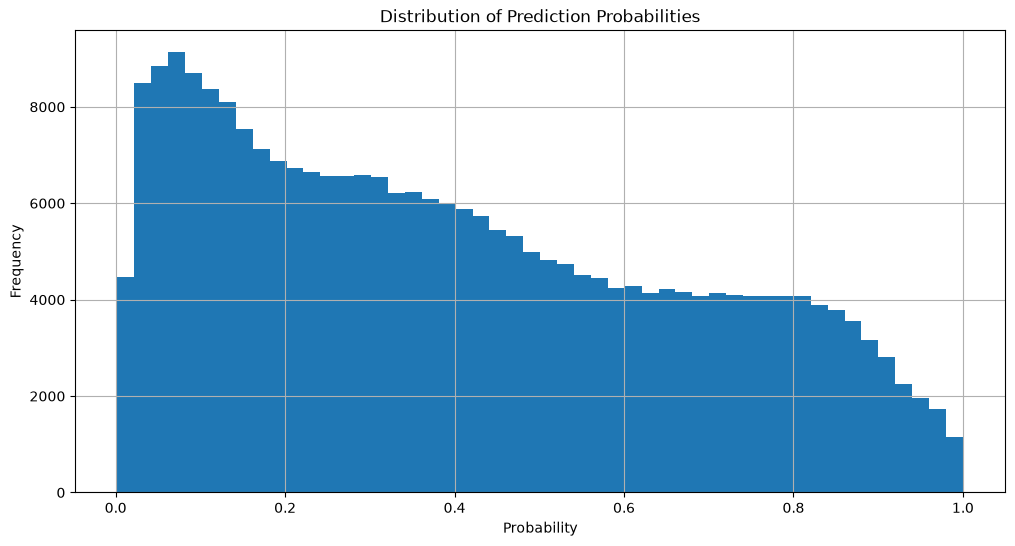

In [22]:
# ============================================================
# Probability Distribution
# ============================================================

plt.figure(figsize=(12,6))

plt.hist(
    probabilities_np.flatten(),
    bins=50
)

plt.title("Distribution of Prediction Probabilities")

plt.xlabel("Probability")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

In [23]:
# ============================================================
# Save Inference Results
# ============================================================

np.save(
    EVAL_DIR / "labels.npy",
    labels_np
)

np.save(
    EVAL_DIR / "probabilities.npy",
    probabilities_np
)

np.save(
    EVAL_DIR / "predictions.npy",
    predictions_np
)

print("=" * 60)
print("Inference Results Saved")
print("=" * 60)
print(EVAL_DIR)

Inference Results Saved
c:\Users\HP\MED-AGENT\outputs\evaluation


In [24]:
# ============================================================
# Evaluation Libraries
# ============================================================

from sklearn.metrics import (
    classification_report,
    multilabel_confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_auc_score
)

import seaborn as sns

print("Evaluation Libraries Loaded Successfully.")

Evaluation Libraries Loaded Successfully.


In [25]:
# ============================================================
# Overall Metrics
# ============================================================

overall_precision = precision_score(
    labels_np,
    predictions_np,
    average="macro",
    zero_division=0
)

overall_recall = recall_score(
    labels_np,
    predictions_np,
    average="macro",
    zero_division=0
)

overall_f1 = f1_score(
    labels_np,
    predictions_np,
    average="macro",
    zero_division=0
)

overall_auc = roc_auc_score(
    labels_np,
    probabilities_np,
    average="macro"
)

print("="*60)
print("OVERALL MODEL PERFORMANCE")
print("="*60)

print(f"Macro Precision : {overall_precision:.4f}")
print(f"Macro Recall    : {overall_recall:.4f}")
print(f"Macro F1 Score  : {overall_f1:.4f}")
print(f"Macro AUROC     : {overall_auc:.4f}")

OVERALL MODEL PERFORMANCE
Macro Precision : 0.1488
Macro Recall    : 0.7714
Macro F1 Score  : 0.2138
Macro AUROC     : 0.7990


In [26]:
# ============================================================
# Per Disease Metrics
# ============================================================

metrics_list = []

for i, disease in enumerate(label_columns):

    precision = precision_score(
        labels_np[:, i],
        predictions_np[:, i],
        zero_division=0
    )

    recall = recall_score(
        labels_np[:, i],
        predictions_np[:, i],
        zero_division=0
    )

    f1 = f1_score(
        labels_np[:, i],
        predictions_np[:, i],
        zero_division=0
    )

    auc = roc_auc_score(
        labels_np[:, i],
        probabilities_np[:, i]
    )

    metrics_list.append({

        "Disease": disease,

        "Precision": precision,

        "Recall": recall,

        "F1 Score": f1,

        "AUROC": auc

    })

metrics_df = pd.DataFrame(metrics_list)

metrics_df

,Disease,Precision,Recall,F1 Score,AUROC
0,Atelectasis,0.174656,0.831058,0.288650,0.764009
1,Cardiomegaly,0.078207,0.897177,0.143873,0.888347
2,Consolidation,0.083365,0.863813,0.152055,0.786002
3,Edema,0.056131,0.892216,0.105618,0.876710
4,Effusion,0.258905,0.877331,0.399821,0.854486
5,Emphysema,0.115813,0.771186,0.201383,0.883678
6,Fibrosis,0.042731,0.610108,0.079868,0.773420
7,Hernia,0.008952,0.794118,0.017705,0.902308
8,Infiltration,0.246204,0.733915,0.368716,0.690600
9,Mass,0.102364,0.689474,0.178262,0.770494


In [27]:
# ============================================================
# Save Metrics
# ============================================================

metrics_path = EVAL_DIR / "per_disease_metrics.csv"

metrics_df.to_csv(
    metrics_path,
    index=False
)

print(metrics_path)

c:\Users\HP\MED-AGENT\outputs\evaluation\per_disease_metrics.csv


In [28]:
# ============================================================
# Classification Report
# ============================================================

report = classification_report(

    labels_np,

    predictions_np,

    target_names=label_columns,

    zero_division=0,

    output_dict=True

)

report_df = pd.DataFrame(report).transpose()

report_df

,precision,recall,f1-score,support
Atelectasis,0.174656,0.831058,0.288650,1758.0
Cardiomegaly,0.078207,0.897177,0.143873,496.0
Consolidation,0.083365,0.863813,0.152055,771.0
Edema,0.056131,0.892216,0.105618,334.0
Effusion,0.258905,0.877331,0.399821,2038.0
Emphysema,0.115813,0.771186,0.201383,472.0
Fibrosis,0.042731,0.610108,0.079868,277.0
Hernia,0.008952,0.794118,0.017705,34.0
Infiltration,0.246204,0.733915,0.368716,3093.0
Mass,0.102364,0.689474,0.178262,760.0


In [29]:
# ============================================================
# Save Classification Report
# ============================================================

report_path = EVAL_DIR / "classification_report.csv"

report_df.to_csv(
    report_path
)

print(report_path)

c:\Users\HP\MED-AGENT\outputs\evaluation\classification_report.csv


In [30]:
# ============================================================
# Multi-label Confusion Matrices
# ============================================================

confusion_matrices = multilabel_confusion_matrix(

    labels_np,

    predictions_np

)

print("Total Confusion Matrices :", len(confusion_matrices))

Total Confusion Matrices : 15


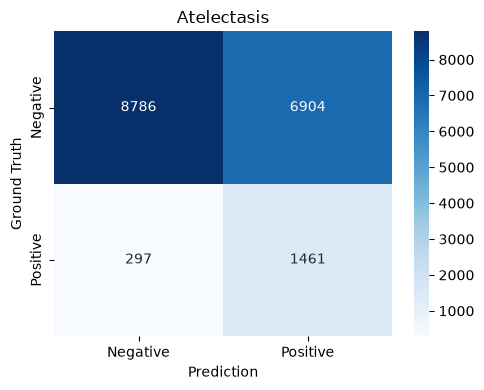

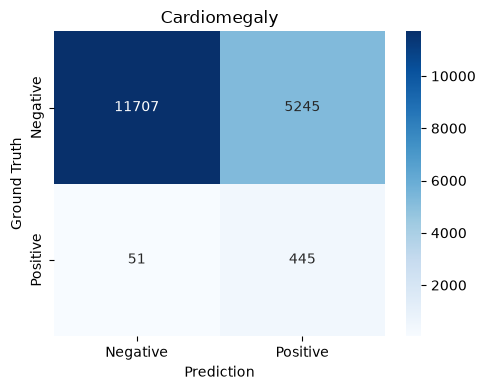

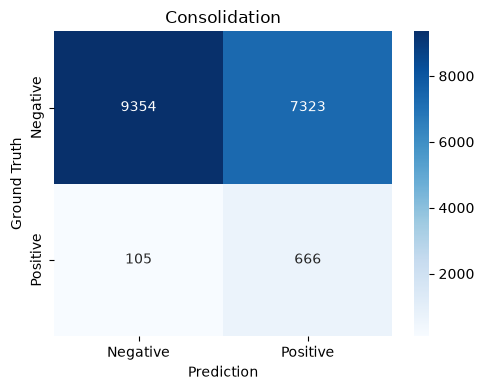

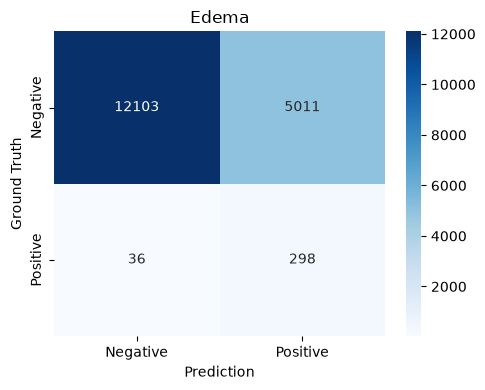

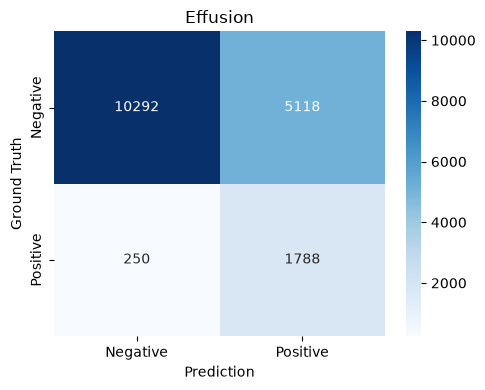

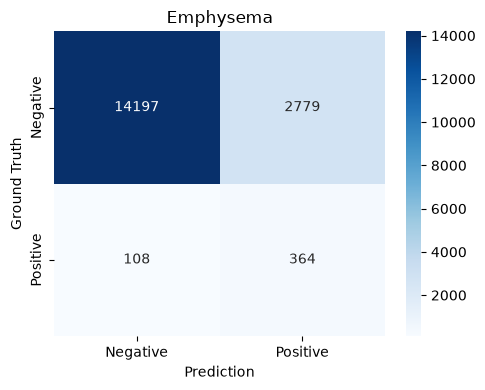

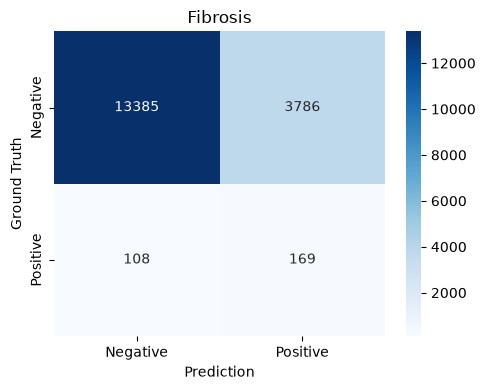

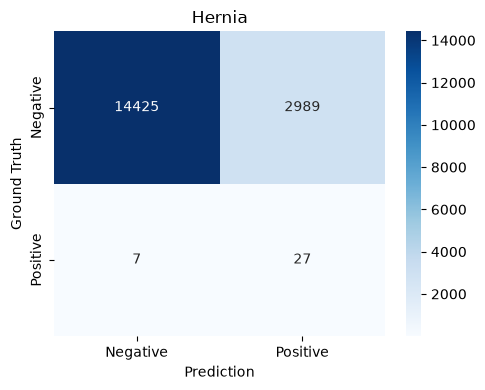

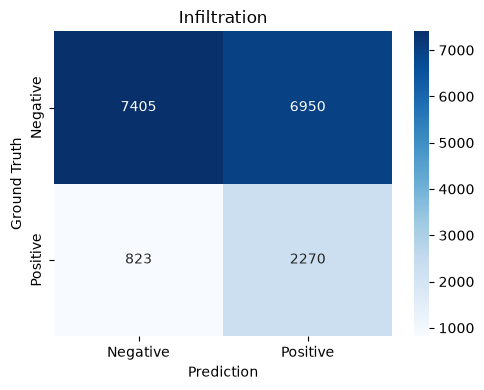

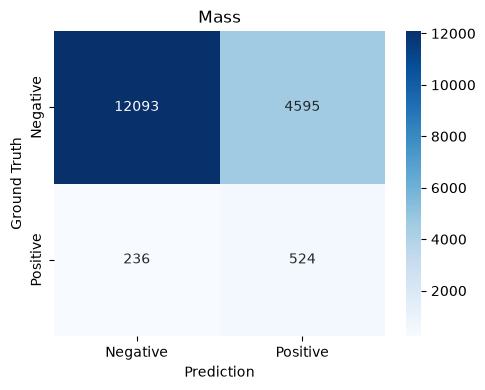

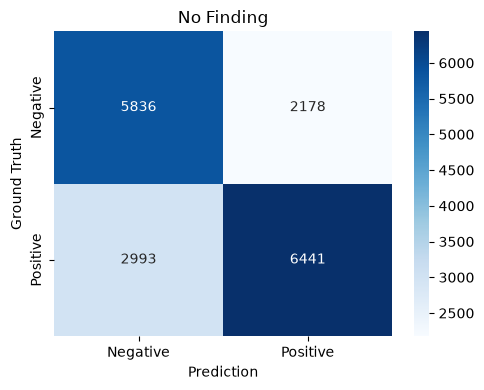

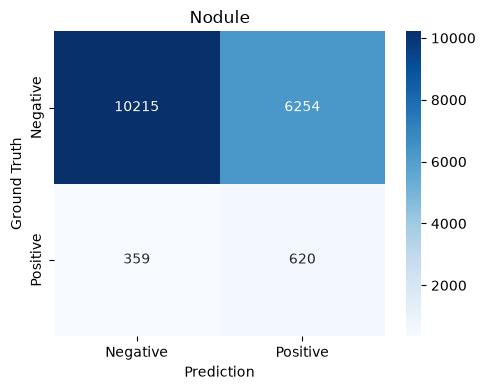

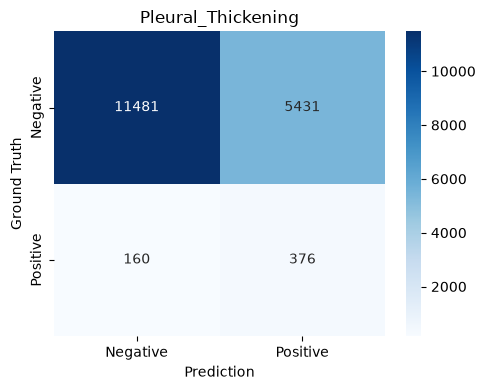

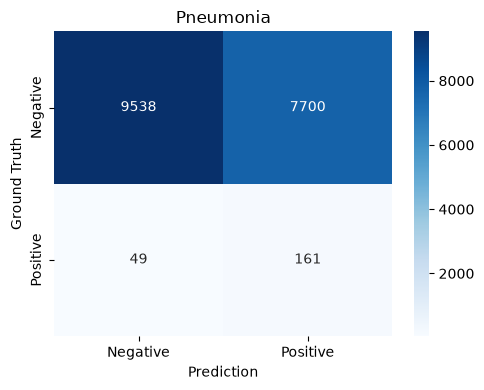

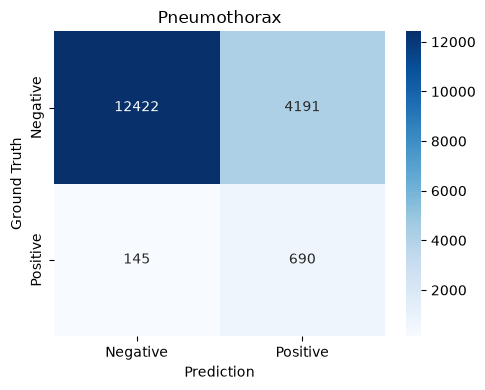

In [31]:
# ============================================================
# Plot Confusion Matrix
# ============================================================

for i, disease in enumerate(label_columns):

    plt.figure(figsize=(5,4))

    sns.heatmap(

        confusion_matrices[i],

        annot=True,

        fmt="d",

        cmap="Blues",

        xticklabels=["Negative","Positive"],

        yticklabels=["Negative","Positive"]

    )

    plt.title(disease)

    plt.xlabel("Prediction")

    plt.ylabel("Ground Truth")

    plt.tight_layout()

    plt.show()

In [32]:
# ============================================================
# Best Performing Diseases
# ============================================================

metrics_df.sort_values(

    by="AUROC",

    ascending=False

).head(10)

,Disease,Precision,Recall,F1 Score,AUROC
7,Hernia,0.008952,0.794118,0.017705,0.902308
1,Cardiomegaly,0.078207,0.897177,0.143873,0.888347
5,Emphysema,0.115813,0.771186,0.201383,0.883678
3,Edema,0.056131,0.892216,0.105618,0.876710
14,Pneumothorax,0.141364,0.826347,0.241428,0.862456
4,Effusion,0.258905,0.877331,0.399821,0.854486
2,Consolidation,0.083365,0.863813,0.152055,0.786002
6,Fibrosis,0.042731,0.610108,0.079868,0.773420
9,Mass,0.102364,0.689474,0.178262,0.770494
0,Atelectasis,0.174656,0.831058,0.288650,0.764009


In [33]:
# ============================================================
# Worst Performing Diseases
# ============================================================

metrics_df.sort_values(

    by="AUROC"

).head(10)

,Disease,Precision,Recall,F1 Score,AUROC
11,Nodule,0.090195,0.633299,0.157901,0.676440
8,Infiltration,0.246204,0.733915,0.368716,0.690600
13,Pneumonia,0.020481,0.766667,0.039896,0.737726
12,Pleural_Thickening,0.064749,0.701493,0.118556,0.757085
10,No Finding,0.747302,0.682743,0.713566,0.760813
0,Atelectasis,0.174656,0.831058,0.288650,0.764009
9,Mass,0.102364,0.689474,0.178262,0.770494
6,Fibrosis,0.042731,0.610108,0.079868,0.773420
2,Consolidation,0.083365,0.863813,0.152055,0.786002
4,Effusion,0.258905,0.877331,0.399821,0.854486


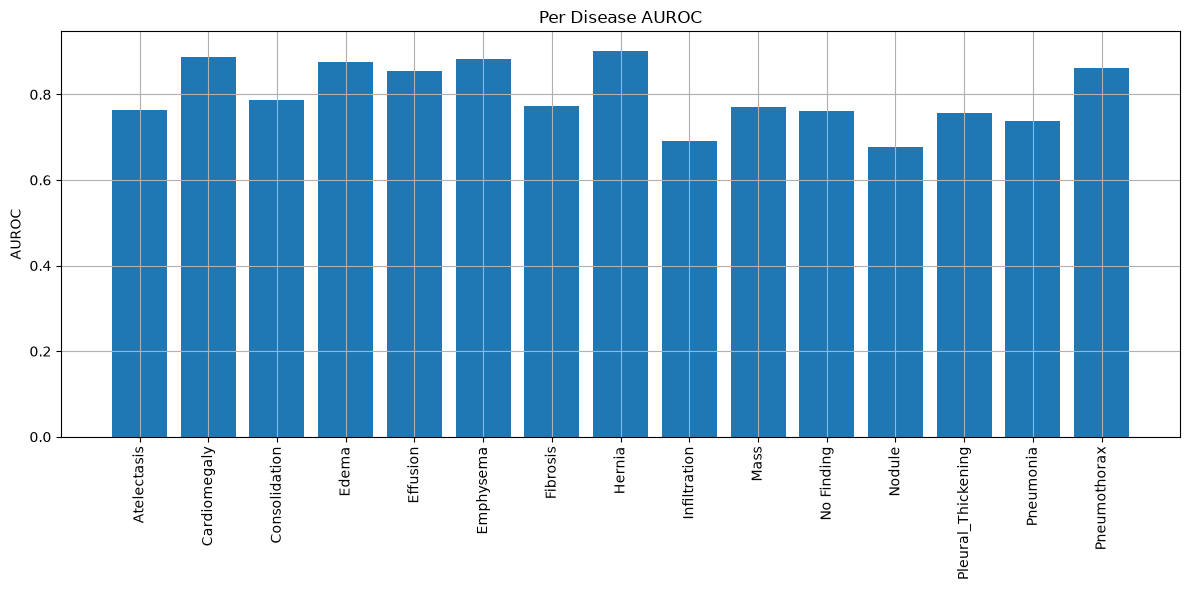

In [34]:
# ============================================================
# AUROC Bar Plot
# ============================================================

plt.figure(figsize=(12,6))

plt.bar(

    metrics_df["Disease"],

    metrics_df["AUROC"]

)

plt.xticks(rotation=90)

plt.ylabel("AUROC")

plt.title("Per Disease AUROC")

plt.grid(True)

plt.tight_layout()

plt.show()

In [35]:
# ============================================================
# Evaluation Summary
# ============================================================

summary = {

    "Macro Precision": float(overall_precision),

    "Macro Recall": float(overall_recall),

    "Macro F1": float(overall_f1),

    "Macro AUROC": float(overall_auc)

}

summary_path = EVAL_DIR / "evaluation_summary.json"

with open(summary_path, "w") as f:

    json.dump(summary, f, indent=4)

print(summary_path)

c:\Users\HP\MED-AGENT\outputs\evaluation\evaluation_summary.json


In [36]:
# ============================================================
# Evaluation Summary
# ============================================================

print("="*70)
print("NOTEBOOK 04 - PART 3 COMPLETED")
print("="*70)

print(f"Macro AUROC    : {overall_auc:.4f}")
print(f"Macro F1       : {overall_f1:.4f}")
print(f"Metrics CSV    : {metrics_path}")
print(f"Report CSV     : {report_path}")
print(f"Summary JSON   : {summary_path}")

NOTEBOOK 04 - PART 3 COMPLETED
Macro AUROC    : 0.7990
Macro F1       : 0.2138
Metrics CSV    : c:\Users\HP\MED-AGENT\outputs\evaluation\per_disease_metrics.csv
Report CSV     : c:\Users\HP\MED-AGENT\outputs\evaluation\classification_report.csv
Summary JSON   : c:\Users\HP\MED-AGENT\outputs\evaluation\evaluation_summary.json


In [37]:
# ============================================================
# Load Validation Dataset
# ============================================================

val_df = pd.read_csv(
    PROCESSED_DIR / "validation_metadata.csv"
)

print("="*60)
print("Validation Dataset")
print("="*60)

print("Shape :", val_df.shape)

display(val_df.head())

Validation Dataset
Shape : (16106, 29)


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Sex,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,...,Emphysema,Fibrosis,Hernia,Infiltration,Mass,No Finding,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax
0,00000007_000.png,No Finding,0,7,82,M,PA,2500,2048,0.168,...,0,0,0,0,0,1,0,0,0,0
1,00000008_000.png,Cardiomegaly,0,8,68,F,PA,2048,2500,0.171,...,0,0,0,0,0,0,0,0,0,0
2,00000008_001.png,No Finding,1,8,70,F,PA,2048,2500,0.171,...,0,0,0,0,0,1,0,0,0,0
3,00000008_002.png,Nodule,2,8,72,F,PA,2048,2500,0.168,...,0,0,0,0,0,0,1,0,0,0
4,00000024_000.png,Fibrosis,0,24,52,M,PA,2048,2500,0.168,...,0,1,0,0,0,0,0,0,0,0


In [38]:
# ============================================================
# Validation Dataset
# ============================================================

val_dataset = ChestXrayDataset(
    dataframe=val_df,
    image_lookup=image_lookup,
    label_columns=label_columns,
    transform=test_transform
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

print("Validation Images :", len(val_dataset))

Validation Images : 16106


In [39]:
# ============================================================
# Validation Inference
# ============================================================

val_labels = []
val_probabilities = []

model.eval()

with torch.no_grad():

    for images, labels in tqdm(val_loader, desc="Validation Inference"):

        images = images.to(DEVICE)

        outputs = model(images)

        probabilities = torch.sigmoid(outputs)

        val_labels.append(labels)

        val_probabilities.append(probabilities.cpu())

val_labels = torch.cat(val_labels).numpy()

val_probabilities = torch.cat(val_probabilities).numpy()

print("Validation Inference Complete")

Validation Inference: 100%|██████████| 504/504 [08:51<00:00,  1.05s/it]

Validation Inference Complete


In [40]:
# ============================================================
# Threshold Optimization Libraries
# ============================================================

from sklearn.metrics import f1_score

print("Libraries Loaded")

Libraries Loaded


In [41]:
# ============================================================
# Find Best Threshold
# ============================================================

def find_best_threshold(y_true, y_prob):

    best_threshold = 0.50
    best_f1 = 0.0

    thresholds = np.arange(0.05, 0.96, 0.01)

    for threshold in thresholds:

        prediction = (y_prob >= threshold).astype(int)

        score = f1_score(
            y_true,
            prediction,
            zero_division=0
        )

        if score > best_f1:

            best_f1 = score
            best_threshold = threshold

    return best_threshold, best_f1

In [42]:
# ============================================================
# Optimize Thresholds
# ============================================================

threshold_results = []

for i, disease in enumerate(label_columns):

    threshold, f1 = find_best_threshold(
        val_labels[:, i],
        val_probabilities[:, i]
    )

    threshold_results.append({

        "Disease": disease,

        "Threshold": threshold,

        "Validation F1": f1

    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Disease,Threshold,Validation F1
0,Atelectasis,0.69,0.335881
1,Cardiomegaly,0.95,0.330709
2,Consolidation,0.83,0.232101
3,Edema,0.94,0.239878
4,Effusion,0.79,0.497122
5,Emphysema,0.85,0.388385
6,Fibrosis,0.77,0.130389
7,Hernia,0.95,0.162162
8,Infiltration,0.66,0.388853
9,Mass,0.80,0.273166


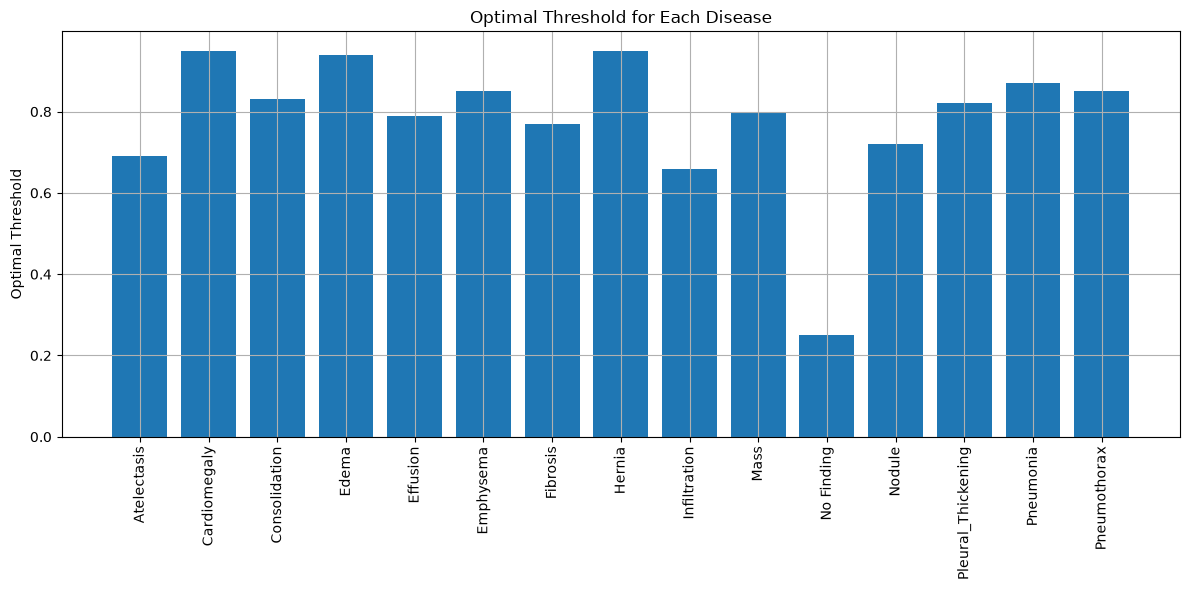

In [43]:
# ============================================================
# Threshold Visualization
# ============================================================

plt.figure(figsize=(12,6))

plt.bar(
    threshold_df["Disease"],
    threshold_df["Threshold"]
)

plt.xticks(rotation=90)

plt.ylabel("Optimal Threshold")

plt.title("Optimal Threshold for Each Disease")

plt.grid(True)

plt.tight_layout()

plt.show()

In [44]:
# ============================================================
# Save Threshold CSV
# ============================================================

threshold_csv = EVAL_DIR / "optimal_thresholds.csv"

threshold_df.to_csv(
    threshold_csv,
    index=False
)

print(threshold_csv)

c:\Users\HP\MED-AGENT\outputs\evaluation\optimal_thresholds.csv


In [45]:
# ============================================================
# Save Threshold JSON
# ============================================================

threshold_dict = dict(
    zip(
        threshold_df["Disease"],
        threshold_df["Threshold"]
    )
)

threshold_json = EVAL_DIR / "optimal_thresholds.json"

with open(threshold_json, "w") as f:

    json.dump(
        threshold_dict,
        f,
        indent=4
    )

print(threshold_json)

c:\Users\HP\MED-AGENT\outputs\evaluation\optimal_thresholds.json


In [46]:
# ============================================================
# Threshold Summary
# ============================================================

print("="*60)

print("Threshold Optimization Complete")

print("="*60)

display(threshold_df)

print()

print(f"Average Threshold : {threshold_df['Threshold'].mean():.3f}")

print(f"Lowest Threshold  : {threshold_df['Threshold'].min():.3f}")

print(f"Highest Threshold : {threshold_df['Threshold'].max():.3f}")

Threshold Optimization Complete


,Disease,Threshold,Validation F1
0,Atelectasis,0.69,0.335881
1,Cardiomegaly,0.95,0.330709
2,Consolidation,0.83,0.232101
3,Edema,0.94,0.239878
4,Effusion,0.79,0.497122
5,Emphysema,0.85,0.388385
6,Fibrosis,0.77,0.130389
7,Hernia,0.95,0.162162
8,Infiltration,0.66,0.388853
9,Mass,0.80,0.273166



Average Threshold : 0.783
Lowest Threshold  : 0.250
Highest Threshold : 0.950


In [47]:
# ============================================================
# Comparison with Default Threshold
# ============================================================

comparison = threshold_df.copy()

comparison["Default"] = 0.50

comparison["Difference"] = (

    comparison["Threshold"] -

    comparison["Default"]

)

comparison

,Disease,Threshold,Validation F1,Default,Difference
0,Atelectasis,0.69,0.335881,0.5,0.19
1,Cardiomegaly,0.95,0.330709,0.5,0.45
2,Consolidation,0.83,0.232101,0.5,0.33
3,Edema,0.94,0.239878,0.5,0.44
4,Effusion,0.79,0.497122,0.5,0.29
5,Emphysema,0.85,0.388385,0.5,0.35
6,Fibrosis,0.77,0.130389,0.5,0.27
7,Hernia,0.95,0.162162,0.5,0.45
8,Infiltration,0.66,0.388853,0.5,0.16
9,Mass,0.80,0.273166,0.5,0.30


In [48]:
# ============================================================
# Save Threshold Report
# ============================================================

report_path = EVAL_DIR / "threshold_report.csv"

comparison.to_csv(
    report_path,
    index=False
)

print(report_path)

c:\Users\HP\MED-AGENT\outputs\evaluation\threshold_report.csv


In [49]:
# ============================================================
# Load Optimized Thresholds
# ============================================================

import json

with open(
    EVAL_DIR / "optimal_thresholds.json",
    "r"
) as f:

    optimal_thresholds = json.load(f)

print("="*60)
print("Optimal Thresholds Loaded")
print("="*60)

for disease, threshold in optimal_thresholds.items():
    print(f"{disease:20s} : {threshold:.3f}")

Optimal Thresholds Loaded
Atelectasis          : 0.690
Cardiomegaly         : 0.950
Consolidation        : 0.830
Edema                : 0.940
Effusion             : 0.790
Emphysema            : 0.850
Fibrosis             : 0.770
Hernia               : 0.950
Infiltration         : 0.660
Mass                 : 0.800
No Finding           : 0.250
Nodule               : 0.720
Pleural_Thickening   : 0.820
Pneumonia            : 0.870
Pneumothorax         : 0.850


In [50]:
# ============================================================
# Apply Optimized Thresholds
# ============================================================

optimized_predictions = np.zeros_like(probabilities_np)

for i, disease in enumerate(label_columns):

    threshold = optimal_thresholds[disease]

    optimized_predictions[:, i] = (
        probabilities_np[:, i] >= threshold
    ).astype(int)

print("Optimized Predictions Created")

Optimized Predictions Created


In [51]:
# ============================================================
# Prediction Count Comparison
# ============================================================

default_counts = predictions_np.sum(axis=0)

optimized_counts = optimized_predictions.sum(axis=0)

comparison_df = pd.DataFrame({

    "Disease":label_columns,

    "Default (0.5)":default_counts,

    "Optimized":optimized_counts

})

comparison_df

,Disease,Default (0.5),Optimized
0,Atelectasis,8365.0,4502.0
1,Cardiomegaly,5690.0,633.0
2,Consolidation,7989.0,1559.0
3,Edema,5309.0,983.0
4,Effusion,6906.0,3356.0
5,Emphysema,3143.0,1087.0
6,Fibrosis,3955.0,880.0
7,Hernia,3016.0,269.0
8,Infiltration,9220.0,5448.0
9,Mass,5119.0,1451.0


In [52]:
# ============================================================
# Overall Metrics
# ============================================================

optimized_precision = precision_score(
    labels_np,
    optimized_predictions,
    average="macro",
    zero_division=0
)

optimized_recall = recall_score(
    labels_np,
    optimized_predictions,
    average="macro",
    zero_division=0
)

optimized_f1 = f1_score(
    labels_np,
    optimized_predictions,
    average="macro",
    zero_division=0
)

optimized_auc = roc_auc_score(
    labels_np,
    probabilities_np,
    average="macro"
)

print("="*60)
print("OPTIMIZED PERFORMANCE")
print("="*60)

print(f"Precision : {optimized_precision:.4f}")
print(f"Recall    : {optimized_recall:.4f}")
print(f"F1 Score  : {optimized_f1:.4f}")
print(f"AUROC     : {optimized_auc:.4f}")

OPTIMIZED PERFORMANCE
Precision : 0.2219
Recall    : 0.4355
F1 Score  : 0.2853
AUROC     : 0.7990


In [53]:
# ============================================================
# Before vs After Comparison
# ============================================================

comparison = pd.DataFrame({

    "Metric":[
        "Precision",
        "Recall",
        "F1",
        "AUROC"
    ],

    "Default":[

        overall_precision,

        overall_recall,

        overall_f1,

        overall_auc

    ],

    "Optimized":[

        optimized_precision,

        optimized_recall,

        optimized_f1,

        optimized_auc

    ]

})

comparison["Improvement"] = (

    comparison["Optimized"]

    -

    comparison["Default"]

)

comparison

,Metric,Default,Optimized,Improvement
0,Precision,0.148761,0.221912,0.073151
1,Recall,0.771396,0.435516,-0.335880
2,F1,0.213820,0.285267,0.071447
3,AUROC,0.798972,0.798972,0.000000


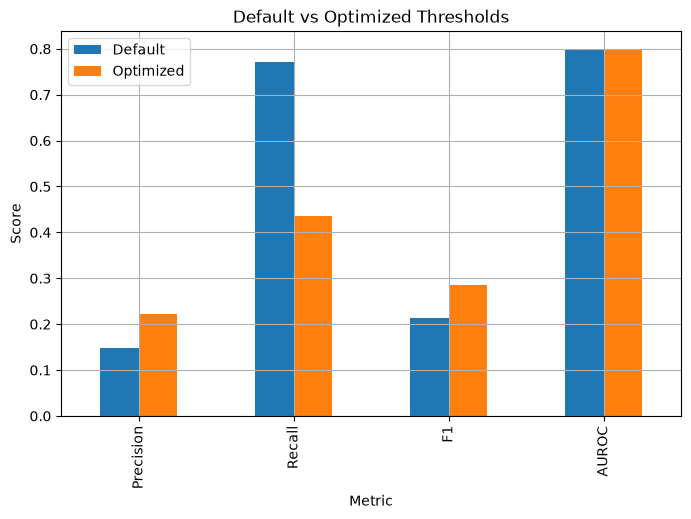

In [54]:
# ============================================================
# Metric Comparison
# ============================================================

comparison.set_index("Metric")[

    ["Default","Optimized"]

].plot(

    kind="bar",

    figsize=(8,5)

)

plt.ylabel("Score")

plt.title("Default vs Optimized Thresholds")

plt.grid(True)

plt.show()

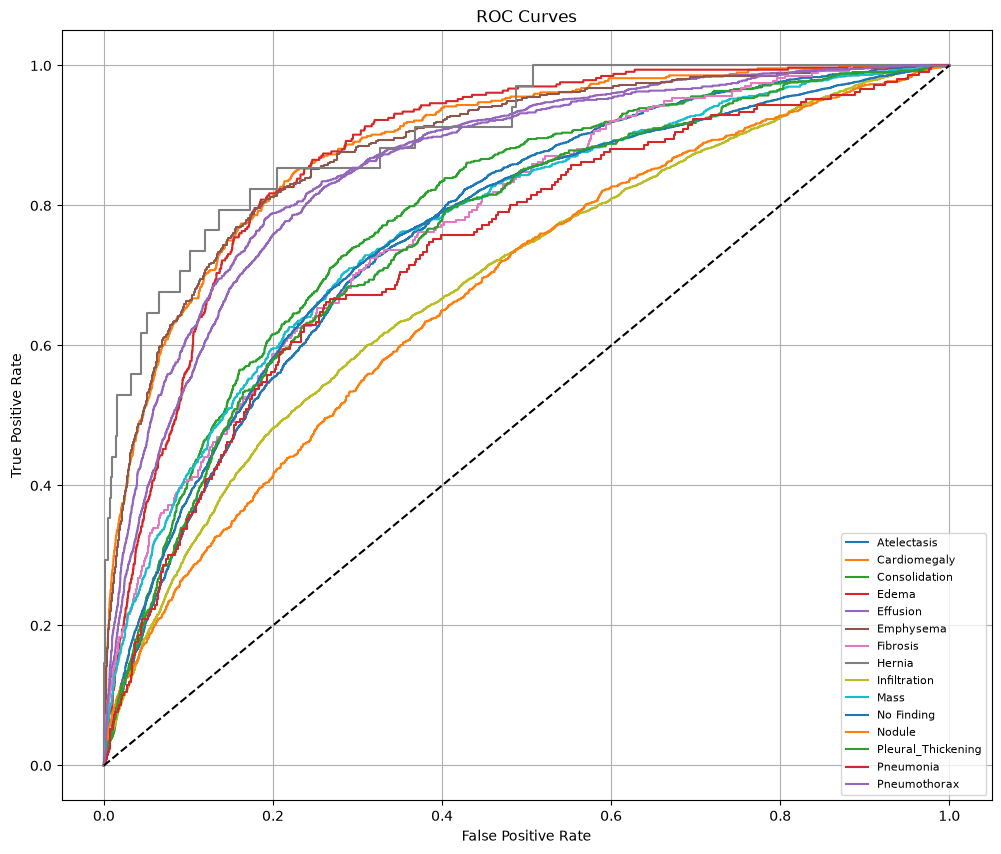

In [55]:
# ============================================================
# ROC Curves
# ============================================================

from sklearn.metrics import roc_curve

plt.figure(figsize=(12,10))

for i, disease in enumerate(label_columns):

    fpr, tpr, _ = roc_curve(

        labels_np[:,i],

        probabilities_np[:,i]

    )

    plt.plot(

        fpr,

        tpr,

        label=f"{disease}"

    )

plt.plot(

    [0,1],

    [0,1],

    linestyle="--",

    color="black"

)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curves")

plt.legend(

    fontsize=8,

    loc="lower right"

)

plt.grid(True)

plt.show()

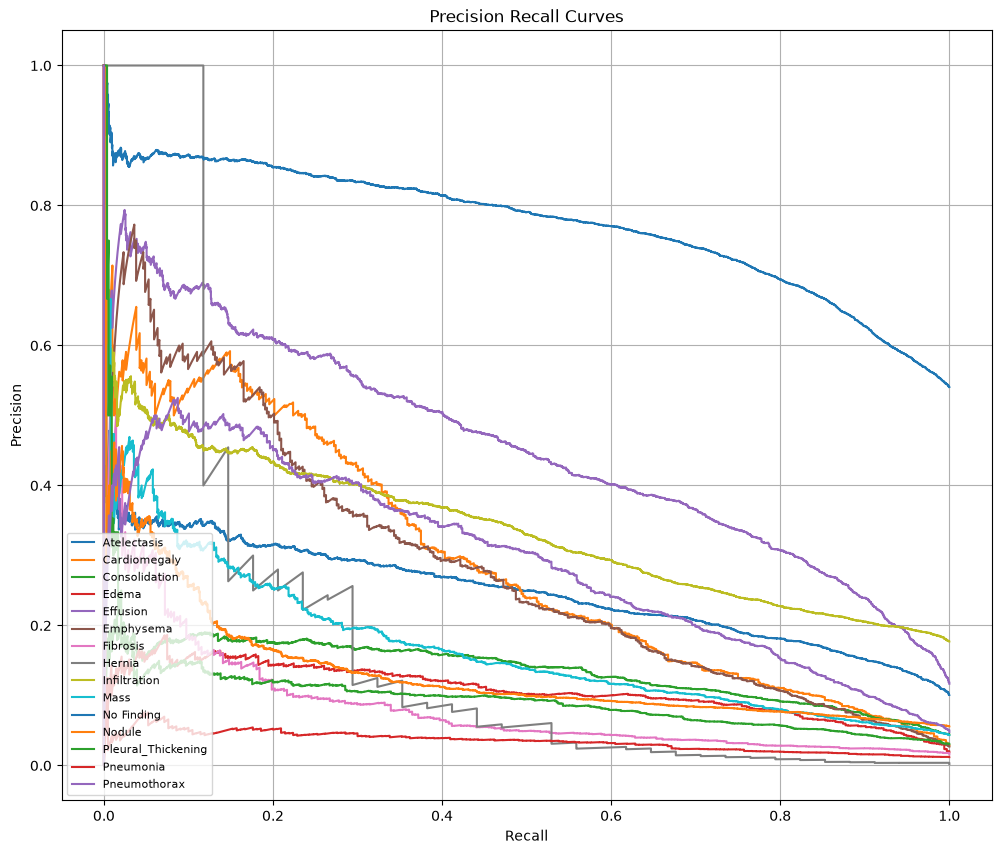

In [56]:
# ============================================================
# Precision Recall Curves
# ============================================================

from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(12,10))

for i, disease in enumerate(label_columns):

    precision, recall, _ = precision_recall_curve(

        labels_np[:,i],

        probabilities_np[:,i]

    )

    plt.plot(

        recall,

        precision,

        label=disease

    )

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision Recall Curves")

plt.legend(

    fontsize=8,

    loc="lower left"

)

plt.grid(True)

plt.show()

In [57]:
# ============================================================
# Save Comparison
# ============================================================

comparison_path = EVAL_DIR / "optimized_vs_default.csv"

comparison.to_csv(

    comparison_path,

    index=False

)

print(comparison_path)

c:\Users\HP\MED-AGENT\outputs\evaluation\optimized_vs_default.csv


In [58]:
# ============================================================
# Save Optimized Metrics
# ============================================================

optimized_metrics = []

for i, disease in enumerate(label_columns):

    precision = precision_score(
        labels_np[:,i],
        optimized_predictions[:,i],
        zero_division=0
    )

    recall = recall_score(
        labels_np[:,i],
        optimized_predictions[:,i],
        zero_division=0
    )

    f1 = f1_score(
        labels_np[:,i],
        optimized_predictions[:,i],
        zero_division=0
    )

    auc = roc_auc_score(
        labels_np[:,i],
        probabilities_np[:,i]
    )

    optimized_metrics.append({

        "Disease":disease,

        "Precision":precision,

        "Recall":recall,

        "F1":f1,

        "AUROC":auc

    })

optimized_df = pd.DataFrame(

    optimized_metrics

)

optimized_df.to_csv(

    EVAL_DIR / "optimized_metrics.csv",

    index=False

)

optimized_df

,Disease,Precision,Recall,F1,AUROC
0,Atelectasis,0.227232,0.581911,0.326837,0.764009
1,Cardiomegaly,0.308057,0.393145,0.345438,0.888347
2,Consolidation,0.163566,0.330739,0.218884,0.786002
3,Edema,0.127162,0.374251,0.189825,0.876710
4,Effusion,0.387068,0.637390,0.481646,0.854486
5,Emphysema,0.225391,0.519068,0.314304,0.883678
6,Fibrosis,0.089773,0.285199,0.136560,0.773420
7,Hernia,0.055762,0.441176,0.099010,0.902308
8,Infiltration,0.309104,0.544455,0.394333,0.690600
9,Mass,0.177808,0.339474,0.233379,0.770494


In [59]:
# ============================================================
# Summary
# ============================================================

print("="*70)
print("PART 4B COMPLETED")
print("="*70)

print()

print("Files Generated")

print()

print("✓ optimized_metrics.csv")

print("✓ optimized_vs_default.csv")

print("✓ ROC Curves")

print("✓ Precision Recall Curves")

print("✓ Optimized Predictions")

print()

print("Ready for Part 5 : Error Analysis")

PART 4B COMPLETED

Files Generated

✓ optimized_metrics.csv
✓ optimized_vs_default.csv
✓ ROC Curves
✓ Precision Recall Curves
✓ Optimized Predictions

Ready for Part 5 : Error Analysis


In [60]:
# ============================================================
# Overall Statistics
# ============================================================

print("=" * 60)
print("ERROR ANALYSIS")
print("=" * 60)

total_images = labels_np.shape[0]

correct = (optimized_predictions == labels_np).sum()

total_predictions = labels_np.size

accuracy = correct / total_predictions

print(f"Total Images      : {total_images}")
print(f"Total Predictions : {total_predictions}")
print(f"Correct Labels    : {correct}")
print(f"Overall Accuracy  : {accuracy:.4f}")

ERROR ANALYSIS
Total Images      : 17448
Total Predictions : 261720
Correct Labels    : 230468
Overall Accuracy  : 0.8806


In [61]:
# ============================================================
# Per Disease Error Counts
# ============================================================

error_table = []

for i, disease in enumerate(label_columns):

    tp = np.sum(
        (labels_np[:, i] == 1) &
        (optimized_predictions[:, i] == 1)
    )

    tn = np.sum(
        (labels_np[:, i] == 0) &
        (optimized_predictions[:, i] == 0)
    )

    fp = np.sum(
        (labels_np[:, i] == 0) &
        (optimized_predictions[:, i] == 1)
    )

    fn = np.sum(
        (labels_np[:, i] == 1) &
        (optimized_predictions[:, i] == 0)
    )

    error_table.append({

        "Disease": disease,

        "TP": tp,

        "TN": tn,

        "FP": fp,

        "FN": fn

    })

error_df = pd.DataFrame(error_table)

display(error_df)

,Disease,TP,TN,FP,FN
0,Atelectasis,1023,12211,3479,735
1,Cardiomegaly,195,16514,438,301
2,Consolidation,255,15373,1304,516
3,Edema,125,16256,858,209
4,Effusion,1299,13353,2057,739
5,Emphysema,245,16134,842,227
6,Fibrosis,79,16370,801,198
7,Hernia,15,17160,254,19
8,Infiltration,1684,10591,3764,1409
9,Mass,258,15495,1193,502


In [62]:
error_report_path = EVAL_DIR / "error_analysis.csv"

error_df.to_csv(
    error_report_path,
    index=False
)

print(error_report_path)

c:\Users\HP\MED-AGENT\outputs\evaluation\error_analysis.csv


In [63]:
test_metadata = test_df.reset_index(drop=True)

print(test_metadata.head())

        Image Index Finding Labels  Follow-up #  Patient ID  Patient Age  \
0  00000004_000.png    Mass|Nodule            0           4           82   
1  00000018_000.png     No Finding            0          18           75   
2  00000035_000.png     No Finding            0          35           79   
3  00000035_001.png     No Finding            1          35           80   
4  00000045_000.png   Cardiomegaly            0          45           70   

  Patient Sex View Position  OriginalImage[Width  Height]  \
0           M            AP                 2500     2048   
1           M            PA                 2500     2048   
2           M            PA                 2754     2873   
3           M            PA                 2718     2973   
4           F            PA                 2500     2048   

   OriginalImagePixelSpacing[x  ...  Emphysema  Fibrosis  Hernia Infiltration  \
0                        0.168  ...          0         0       0            0   
1             

In [64]:
# ============================================================
# Visualization Function
# ============================================================

def visualize_prediction(index):

    row = test_metadata.iloc[index]

    image_name = row["Image Index"]

    image_path = image_lookup[image_name]

    image = Image.open(image_path).convert("L")

    plt.figure(figsize=(6,6))

    plt.imshow(image, cmap="gray")

    plt.axis("off")

    plt.title(image_name)

    plt.show()

    print("=" * 60)

    print("Ground Truth")

    gt = []

    pred = []

    for i, disease in enumerate(label_columns):

        if labels_np[index][i] == 1:

            gt.append(disease)

        if optimized_predictions[index][i] == 1:

            pred.append(disease)

    print(gt)

    print()

    print("Prediction")

    print(pred)

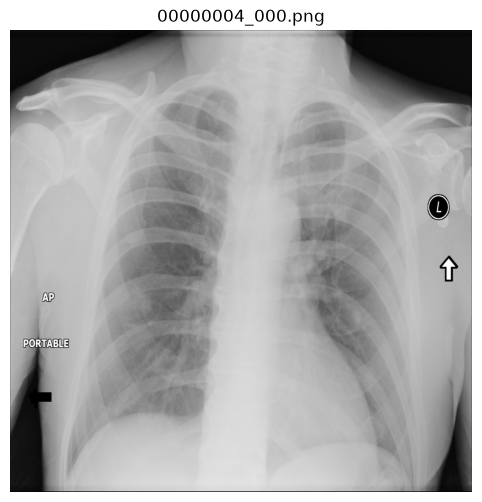

Ground Truth
['Mass', 'Nodule']

Prediction
['No Finding']


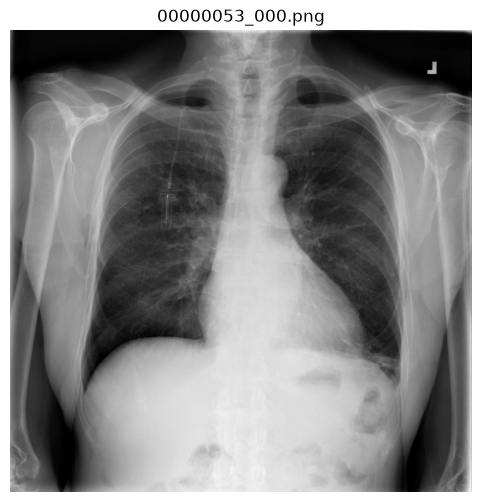

Ground Truth
['Fibrosis', 'Infiltration', 'Nodule']

Prediction
['Atelectasis', 'Hernia']


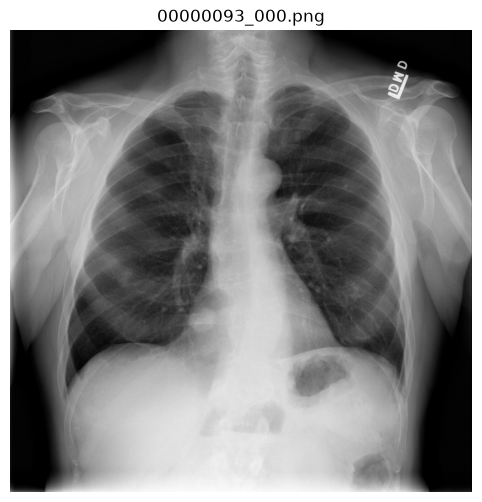

Ground Truth
['Nodule']

Prediction
['No Finding']


In [65]:
visualize_prediction(0)

visualize_prediction(5)

visualize_prediction(10)

In [66]:
confidence = np.max(probabilities_np, axis=1)

confidence_df = pd.DataFrame({

    "Image": test_metadata["Image Index"],

    "Confidence": confidence

})

confidence_df.head()

,Image,Confidence
0,00000004_000.png,0.791428
1,00000018_000.png,0.866432
2,00000035_000.png,0.657583
3,00000035_001.png,0.897882
4,00000045_000.png,0.992196


In [67]:
confidence_df.sort_values(

    by="Confidence",

    ascending=False

).head(20)

,Image,Confidence
3149,00005175_004.png,0.999995
3148,00005175_003.png,0.999990
17240,00030137_008.png,0.999963
3147,00005175_005.png,0.999957
9552,00015530_086.png,0.999940
9553,00015530_087.png,0.999936
12930,00020499_007.png,0.999924
2137,00003523_035.png,0.999913
2138,00003523_037.png,0.999870
9551,00015530_085.png,0.999804


In [68]:
confidence_df.sort_values(

    by="Confidence"

).head(20)

,Image,Confidence
9996,00015838_000.png,0.533002
11025,00017306_000.png,0.534238
865,00001458_000.png,0.534459
8763,00014427_013.png,0.538888
6659,00011509_001.png,0.540597
6962,00011934_001.png,0.543412
11291,00017777_000.png,0.546441
12994,00020587_000.png,0.546874
15047,00025650_009.png,0.549013
16544,00028682_001.png,0.550797


In [69]:
generated_files = [

    "classification_report.csv",

    "per_disease_metrics.csv",

    "evaluation_summary.json",

    "optimal_thresholds.json",

    "optimal_thresholds.csv",

    "optimized_metrics.csv",

    "optimized_vs_default.csv",

    "threshold_report.csv",

    "error_analysis.csv"

]

print("=" * 60)

print("Generated Files")

print("=" * 60)

for file in generated_files:

    print(file)

Generated Files
classification_report.csv
per_disease_metrics.csv
evaluation_summary.json
optimal_thresholds.json
optimal_thresholds.csv
optimized_metrics.csv
optimized_vs_default.csv
threshold_report.csv
error_analysis.csv


In [70]:
print("=" * 70)
print("NOTEBOOK 4 COMPLETED")
print("=" * 70)

print()

print("Evaluation Pipeline Completed")

print()

print("Model Used           : DenseNet121")

print("Loss Function        : BCEWithLogitsLoss")

print("Evaluation Dataset   : Test Set")

print("Threshold Strategy   : Validation Optimized")

print()

print("Outputs Saved To")

print(EVAL_DIR)

print()

print("Ready for Notebook 5 (Grad-CAM)")

NOTEBOOK 4 COMPLETED

Evaluation Pipeline Completed

Model Used           : DenseNet121
Loss Function        : BCEWithLogitsLoss
Evaluation Dataset   : Test Set
Threshold Strategy   : Validation Optimized

Outputs Saved To
c:\Users\HP\MED-AGENT\outputs\evaluation

Ready for Notebook 5 (Grad-CAM)
